In [3]:
import os
import time
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

from diff_multi_frame import GrainDiffusionUNet, NoiseScheduler

# --- CONFIGURATION ---
ROOT_DIR = "/home/hice1/vyadav68/scratch/grain_growth/dataset/grain_images"
MODEL_PATH = "/home/hice1/vyadav68/scratch/grain_growth/diff_multi_frame/final_model_3 frame/grain_diffusion_final.pt"
IMAGE_SIZE = 512
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_PAST_FRAMES = 3    
NUM_FUTURE_FRAMES = 3  

print(f"Running Inference on: {device} | History: {NUM_PAST_FRAMES} frames")

# --- LOAD MODEL & SCHEDULER ---
model = GrainDiffusionUNet(
    num_past_frames=NUM_PAST_FRAMES,
    num_future_frames=NUM_FUTURE_FRAMES,
    base_channels=64, context_dim=256, embed_dim=128
).to(device)

checkpoint = torch.load(MODEL_PATH, map_location=device)
state_dict = checkpoint["model_state"]

# Clean the torch.compile prefix from the saved weights
clean_state_dict = {}
for k, v in state_dict.items():
    clean_key = k.replace("_orig_mod.", "")
    clean_state_dict[clean_key] = v

model.load_state_dict(clean_state_dict)
model.eval()

scheduler = NoiseScheduler(num_timesteps=1000)

# --- DATA HELPERS ---
grain_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

boundary_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

def load_rgb(run_id, temp, step):
    path = os.path.join(ROOT_DIR, f"timestep_{step}", f"run_{run_id}_temp_{temp:.3f}_timestep_{step}_rgb.png")
    return grain_transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)

def load_boundary(run_id, temp, step):
    path = os.path.join(ROOT_DIR, f"timestep_{step}", f"run_{run_id}_temp_{temp:.3f}_timestep_{step}_boundary.png")
    boundary = boundary_transform(Image.open(path).convert("L")).unsqueeze(0).to(device)
    return 1.0 - boundary # 1=boundary

def get_sobel_edges(tensor_img):
    gray = tensor_img.mean(dim=1, keepdim=True)
    sx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32, device=device).view(1,1,3,3)
    sy = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32, device=device).view(1,1,3,3)
    ex = F.conv2d(gray, sx, padding=1)
    ey = F.conv2d(gray, sy, padding=1)
    edges = torch.sqrt(ex**2 + ey**2)
    return (edges / (edges.max() + 1e-6)).squeeze().cpu().numpy()

Running Inference on: cuda | History: 3 frames


Predicting T=[300, 400, 500] from history T=[0, 100, 200]
  Step 750/1000...
  Step 500/1000...
  Step 250/1000...
  Step 0/1000...
Done in 17.7s

--- Sequence Metrics ---
T=300 | MSE: 0.0321 | PSNR: 14.93 dB | SSIM: 0.6281
T=400 | MSE: 0.0418 | PSNR: 13.79 dB | SSIM: 0.6264
T=500 | MSE: 0.0468 | PSNR: 13.30 dB | SSIM: 0.6222


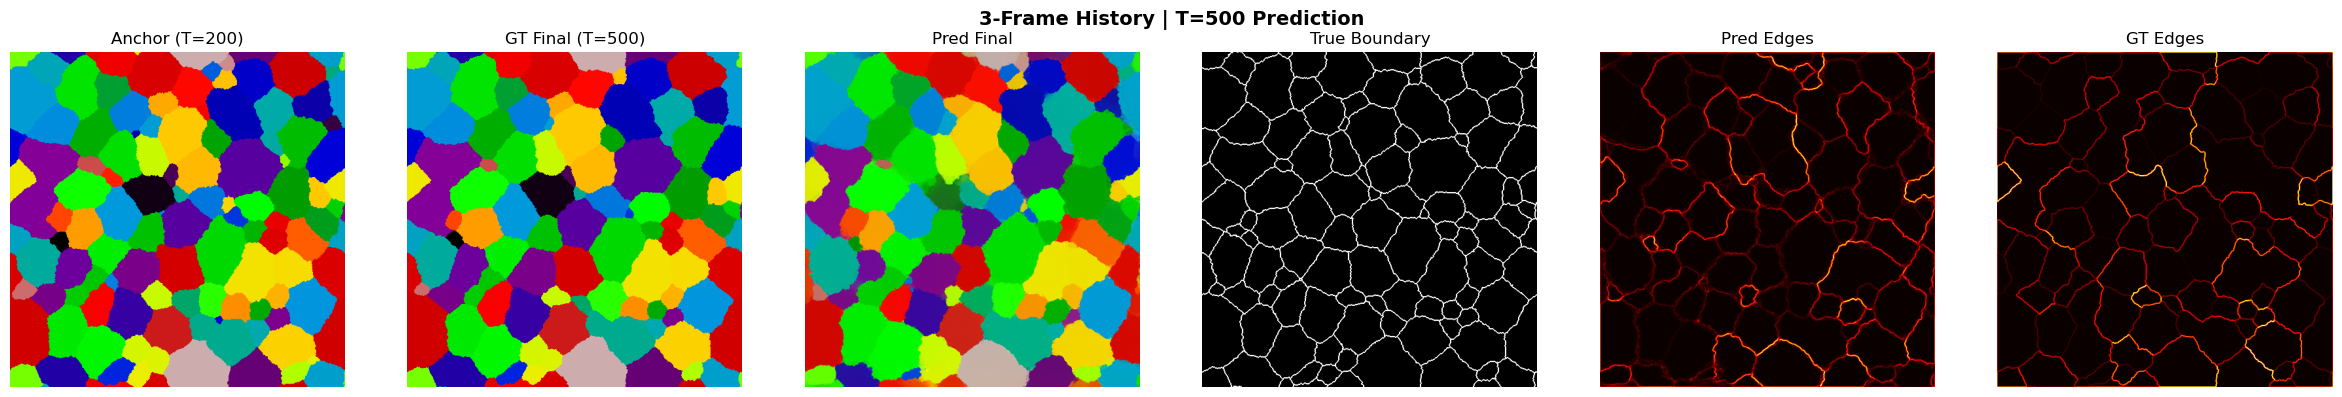

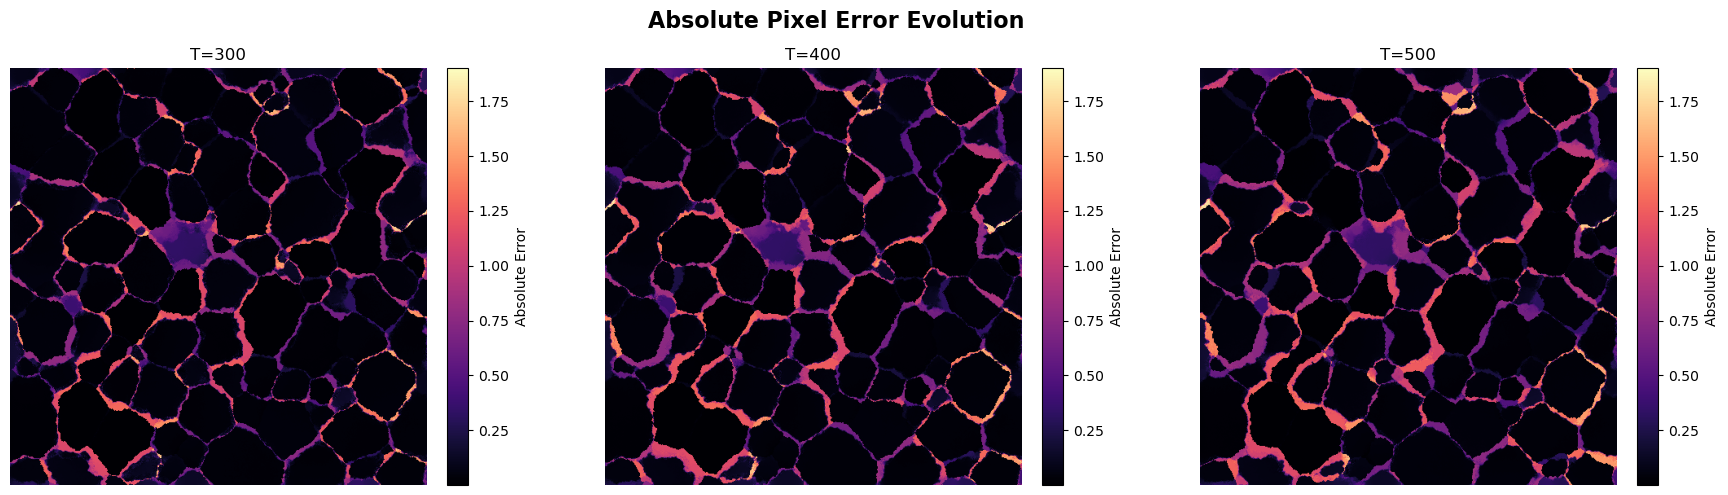

In [5]:
# --- SELECT TARGETS ---
run_id = 100  # Change to any valid run ID
temp = 0.882  # Change to actual temp for the run
past_timesteps = [0, 100, 200]
target_timesteps = [300, 400, 500]

print(f"Predicting T={target_timesteps} from history T={past_timesteps}")

# Load Past Frames & Stack them into 9 channels
past_tensors = [load_rgb(run_id, temp, t) for t in past_timesteps]
past_frames_stacked = torch.cat(past_tensors, dim=1) # (1, 9, H, W)
init_image = past_tensors[-1] # The immediate anchor (T=200)

# Load Ground Truth for ALL Future Frames
gt_rgb_frames = [load_rgb(run_id, temp, t) for t in target_timesteps]
# Keep the final boundary for the 6-panel plot
gt_boundary_final = load_boundary(run_id, temp, target_timesteps[-1]) 

start_time = time.time()

# --- INFERENCE ---
with torch.no_grad():
    past_context = model.get_past_context(past_frames_stacked)
    canvas = torch.randn(1, NUM_FUTURE_FRAMES * 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    temp_tensor = torch.tensor([temp], device=device)
    # The jump is to the FINAL frame in the sequence
    jump_tensor = torch.tensor([float(target_timesteps[-1] - past_timesteps[-1])], device=device)
    
    for t in reversed(range(1000)):
        if t % 250 == 0: print(f"  Step {t}/1000...")
        diff_step = torch.tensor([t], device=device)
        pred_noise = model(
            canvas, init_image, diff_step, jump_tensor, temp_tensor, 
            precomputed_context=past_context
        )
        canvas = scheduler.ddpm_step(canvas, pred_noise, t, device)
        
pred_clean_stacked = canvas.clamp(-1, 1)

# Split the 9-channel tensor back into 3 separate RGB frames
predicted_frames = torch.chunk(pred_clean_stacked, chunks=NUM_FUTURE_FRAMES, dim=1)
print(f"Done in {time.time()-start_time:.1f}s")

# --- MULTI-FRAME METRICS ---
print(f"\n--- Sequence Metrics ---")
for i, t_target in enumerate(target_timesteps):
    pred_frame = predicted_frames[i]
    gt_frame = gt_rgb_frames[i]
    
    pred_np = pred_frame[0].cpu().numpy().transpose(1, 2, 0) * 0.5 + 0.5
    gt_np = gt_frame[0].cpu().numpy().transpose(1, 2, 0) * 0.5 + 0.5

    mse = np.mean((pred_np - gt_np) ** 2)
    psnr = psnr_metric(gt_np, pred_np, data_range=1.0)
    ssim = ssim_metric(gt_np, pred_np, data_range=1.0, channel_axis=-1)
    
    print(f"T={t_target} | MSE: {mse:.4f} | PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f}")

# --- VISUALIZATION: FINAL FRAME 6-PANEL ---
pred_final_frame = predicted_frames[-1]
gt_rgb_final = gt_rgb_frames[-1]

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
fig.suptitle(f"3-Frame History | T={target_timesteps[-1]} Prediction", fontsize=14, fontweight='bold')

images = [
    init_image[0].cpu().permute(1,2,0)*0.5+0.5, 
    gt_rgb_final[0].cpu().permute(1,2,0)*0.5+0.5, 
    pred_final_frame[0].cpu().permute(1,2,0)*0.5+0.5,
    gt_boundary_final[0].cpu().squeeze(0),         
    get_sobel_edges(pred_final_frame),             
    get_sobel_edges(gt_rgb_final.clamp(0, 1))   
]
titles = [f"Anchor (T={past_timesteps[-1]})", f"GT Final (T={target_timesteps[-1]})", f"Pred Final", "True Boundary", "Pred Edges", "GT Edges"]
cmaps = [None, None, None, "gray", "hot", "hot"]

for ax, title, img, cmap in zip(axes, titles, images, cmaps):
    ax.imshow(img.numpy() if torch.is_tensor(img) else img, cmap=cmap)
    ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

# --- MULTI-FRAME ERROR HEATMAPS ---
fig, axes = plt.subplots(1, NUM_FUTURE_FRAMES, figsize=(18, 5))
fig.suptitle("Absolute Pixel Error Evolution", fontsize=16, fontweight='bold')

for i, t_target in enumerate(target_timesteps):
    pred_frame = predicted_frames[i]
    gt_frame = gt_rgb_frames[i]
    
    # Calculate error map
    error_map = torch.abs(pred_frame - gt_frame).mean(dim=1)[0].cpu().numpy()
    
    ax = axes[i]
    im = ax.imshow(error_map, cmap='magma') 
    ax.set_title(f"T={t_target}")
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Absolute Error')

plt.tight_layout()
plt.show()